In [1]:
from implementations.london_graph import LondonTubeGraph
from implementations.modified_dijkstra import dijkstra
from implementations.a_star import a_star
import time
import numpy as np
import random
import matplotlib.pyplot as plt

# initialise our graph, load stations/connections
graph = LondonTubeGraph()
graph.load_stations("data/london_stations.csv")
graph.load_connections("data/london_connections.csv")

max_speed, best_pair = graph.calculate_max_speed()
print(f"""Maximum network speed is {max_speed}km / m, found from {best_pair[0]} to {best_pair[1]} (line: {best_pair[2]}). 
      Our heuristic for station 1 to 52 is {graph.calculate_heuristic(1,52,max_speed)}""")
# create heuristic dict

# for k, h in h_mapped.items():
#     print(h)

# pred, path = a_star(graph, 256, 158, h_mapped[256])
# print(path)

# graph.print_station(256)
# graph.print_station(88)
# graph.print_station(68)

Maximum network speed is 1.2765562645782353km / m, found from 88 to 256 (line: 2). 
      Our heuristic for station 1 to 52 is 0.9772584682446565


In [13]:
def count_line_changes(graph, path):
        """
        Takes a path (list of station IDs) and calculates the number of line transfers.
        """
        if len(path) < 2:
            return 0
            
        transfers = 0
        # Get the line for the very first jump
        current_line = graph.lines[(path[0], path[1])]
        
        # Walk through the rest of the path
        for i in range(1, len(path) - 1):
            u = path[i]
            v = path[i+1]
            next_line = graph.lines[(u, v)]
            
            # If the line changes, we made a transfer
            if next_line != current_line:
                transfers += 1
                current_line = next_line
                
        return transfers

def calculate_true_path_time(G, path):
    """Sums the edge weights (time in mins) along a given path."""
    if len(path) < 2: return 0
    total_time = 0
    for i in range(len(path)-1):
        total_time += G.w(path[i], path[i+1])
    return total_time

In [ ]:
# EXPERIMENT 1: Testing on pairs of 2 randomly chosen stations
# NOTE: for fair testing, we slightly modify Dijkstra for point ot point, instead of all paths

# def test_suite1(G, heuristic_dicts, tests=100, iterations=15):
#     stations = list(G.station_info.keys())
#     dijkstra_times, a_star_times, path_lengths = [], [], []

#     print(f"Running Suite 1: {tests} routes ({iterations} iterations per route)...")
#     for _ in range(tests):
#         s, d = random.sample(stations, 2)

#         best_d_time = float('inf')
#         best_a_time = float('inf')
#         d_path = []

#         # run 15 times, keep the fastest to eliminate OS noise
#         for _ in range(iterations):
#             # Test Dijkstra
#             start = time.perf_counter()
#             _, cur_d_path = dijkstra(G, s, d)
#             t = (time.perf_counter() - start) * 1000
#             if t < best_d_time: best_d_time = t
#             d_path = cur_d_path # save the path to check length later

#             # Test A* 
#             start = time.perf_counter()
#             _, _ = a_star(G, s, d, heuristic_dicts[d]) 
#             t = (time.perf_counter() - start) * 1000
#             if t < best_a_time: best_a_time = t

#         if len(d_path) > 0:
#             dijkstra_times.append(best_d_time)
#             a_star_times.append(best_a_time)
#             path_lengths.append(len(d_path))

#     print("Completed Suite 1")
#     generate_plot(dijkstra_times, a_star_times, path_lengths)

def test_suite_1_speedup(G, tests=500, iterations=15):
    stations = list(G.station_info.keys())
    path_lengths = []
    speedup_factors = []
    a_star_wins = 0
    max_speed, _ = G.calculate_max_speed()

    print(f"Running Suite 1: {tests} routes...")
    for _ in range(tests):
        s, d = random.sample(stations, 2)
        best_d_time, best_a_time = float('inf'), float('inf')
        d_path = []

        for _ in range(iterations):
            start = time.perf_counter()
            _, cur_d_path, _ = dijkstra(G, s, d)
            t = (time.perf_counter() - start) * 1000
            if t < best_d_time: best_d_time = t
            d_path = cur_d_path



            start = time.perf_counter()
            dynamic_h = G.generate_heuristic_for_destination(d, max_speed)
            _, _, _= a_star(G, s, d, dynamic_h) 
            t = (time.perf_counter() - start) * 1000
            if t < best_a_time: best_a_time = t

        if len(d_path) > 0 and best_a_time > 0:
            speedup = best_d_time / best_a_time
            speedup_factors.append(speedup)
            path_lengths.append(len(d_path))
            if speedup > 1.0: a_star_wins += 1

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.scatter(path_lengths, speedup_factors, color='#9b59b6', alpha=0.6, marker='o')
    
    # draw the  tie line 1.0
    ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Tie Line (Speedup = 1.0)')
    
    win_rate = (a_star_wins / len(path_lengths)) * 100
    ax.set_title(f'A* Speedup Multiplier vs Path Length (A* Win Rate: {win_rate:.1f}%)')
    ax.set_xlabel('Path Length (Number of Stops)')
    ax.set_ylabel('Speedup Factor (Dijkstra Time / A* Time)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.show()


def test_suite_2_transfers(G, tests=500, iterations=10):
    # get all stations for random sampling
    stations = list(G.station_info.keys())
    
    # dictionary to hold speedup ratios grouped by transfer count
    data_by_transfers = {} 

    # calculate max network speed once outside the loop
    max_speed, _ = G.calculate_max_speed()

    print(f"Running Suite 2: {tests} routes...")
    for _ in range(tests):
        s, d = random.sample(stations, 2)

        # dijkstra timing loop
        best_d_time = float('inf')
        d_path = []
        for _ in range(iterations):
            start = time.perf_counter()
            _, cur_d_path, _ = dijkstra(G, s, d)
            t = (time.perf_counter() - start) * 1000
            if t < best_d_time: best_d_time = t
            d_path = cur_d_path

        # honest a star timing loop
        best_a_time = float('inf')
        for _ in range(iterations):
            start = time.perf_counter()
            
            # generate heuristic inside the timing block
            dynamic_h = G.generate_heuristic_for_destination(d, max_speed)
            _, _, _ = a_star(G, s, d, dynamic_h)
            
            t = (time.perf_counter() - start) * 1000
            if t < best_a_time: best_a_time = t

        # process results if valid paths were found
        if len(d_path) > 0 and best_a_time > 0:
            # count transfers using the graph helper function
            transfers = count_line_changes(G, d_path) 
            
            # calculate speedup where greater than 1 means a star won
            speedup = best_d_time / best_a_time 
            
            if transfers not in data_by_transfers:
                data_by_transfers[transfers] = []
            data_by_transfers[transfers].append(speedup)

    # plotting preparation
    # filter out outlier transfer counts that have too few data points for a valid boxplot
    min_samples = 5
    valid_transfers = []
    for t in sorted(list(data_by_transfers.keys())):
        if len(data_by_transfers[t]) >= min_samples:
            valid_transfers.append(t)
            
    plot_data = [data_by_transfers[t] for t in valid_transfers]

    # create figure
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # draw boxplot
    ax.boxplot(plot_data, labels=valid_transfers, patch_artist=True, 
               boxprops=dict(facecolor='#2ecc71', alpha=0.6))
    
    # add sample size labels above each box
    for i in range(len(valid_transfers)):
        y_pos = ax.get_ylim()[1] * 0.95
        sample_size = len(plot_data[i])
        ax.text(i + 1, y_pos, f"n={sample_size}", horizontalalignment='center', size=10, color='gray')

    # draw the break even tie line
    ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Time Tie (Speedup = 1.0)')
    
    ax.set_title('A* Speedup vs Route Complexity (Transfers)')
    ax.set_xlabel('Number of Line Transfers Required')
    ax.set_ylabel('Speedup Factor (Dijkstra Time / A* Time)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# removed heuristic_dicts from parameters
def test_suite_3_break_even(G, tests=800, iterations=15):
    stations = list(G.station_info.keys())
    
    nodes_saved = [] # X-axis
    time_saved = []  # Y-axis

    # calculate max speed once outside loop
    max_speed, _ = G.calculate_max_speed()

    print(f"Running Suite 3: {tests} routes...")
    for _ in range(tests):
        s, d = random.sample(stations, 2)
        
        best_d_time = float('inf')
        for _ in range(iterations):
            start = time.perf_counter()
            _, _, d_nodes = dijkstra(G, s, d)
            t = (time.perf_counter() - start) * 1000
            if t < best_d_time: best_d_time = t

        best_a_time = float('inf')
        a_nodes = 0
        for _ in range(iterations):
            start = time.perf_counter()
            
            # calculate heuristic inside the timing block
            dynamic_h = G.generate_heuristic_for_destination(d, max_speed)
            _, _, a_nodes = a_star(G, s, d, dynamic_h)
            
            t = (time.perf_counter() - start) * 1000
            if t < best_a_time: best_a_time = t

        if d_nodes > 0:
            n_saved = d_nodes - a_nodes
            t_saved = best_d_time - best_a_time
            
            nodes_saved.append(n_saved)
            time_saved.append(t_saved)

    # --- Math & Trendline ---
    # Convert to numpy arrays for math operations
    x = np.array(nodes_saved)
    y = np.array(time_saved)
    
    # Calculate line of best fit (y = mx + b)
    m, b = np.polyfit(x, y, 1)
    
    # Calculate the X-intercept (where y = 0)
    # 0 = mx + b  =>  x = -b / m
    break_even_nodes = -b / m if m != 0 else 0

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Scatter the raw data
    ax.scatter(x, y, color='#95a5a6', alpha=0.5, marker='o', label='Individual Trips')
    
    # Plot the trendline
    ax.plot(x, m*x + b, color='#2c3e50', linewidth=3, label=f'Trendline (Slope: {m:.4f})')
    
    # Draw the Break-Even Thresholds
    ax.axhline(y=0, color='#e74c3c', linestyle='--', linewidth=2, label='Time Tie (0 ms saved)')
    ax.axvline(x=break_even_nodes, color='#27ae60', linestyle='-', linewidth=2, 
               label=f'The Break-Even Point: {break_even_nodes:.1f} Nodes')
    
    ax.set_title(f'A* Overhead Threshold')
    ax.set_xlabel('Nodes Pruned by A* (Dijkstra Nodes - A* Nodes)')
    ax.set_ylabel('Time Saved by A* (Dijkstra Time - A* Time) [ms]')
    
    # Add a text box with the concrete conclusion
    textstr = f"A* starts with a math penalty.\nIt must skip ~{int(break_even_nodes)} nodes\nto beat Dijkstra in time."
    props = dict(boxstyle='round', facecolor='white', alpha=0.9)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=props)

    ax.legend(loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.show()
    
    print(f"To overcome the computational overhead of the Haversine formula,")
    print(f"A* must prune exactly {break_even_nodes:.2f} nodes from the search space.")
    print(f"Or {(break_even_nodes/G.number_of_nodes() * 100):.2f} percent of nodes")

Running Suite 1: 1000 routes...


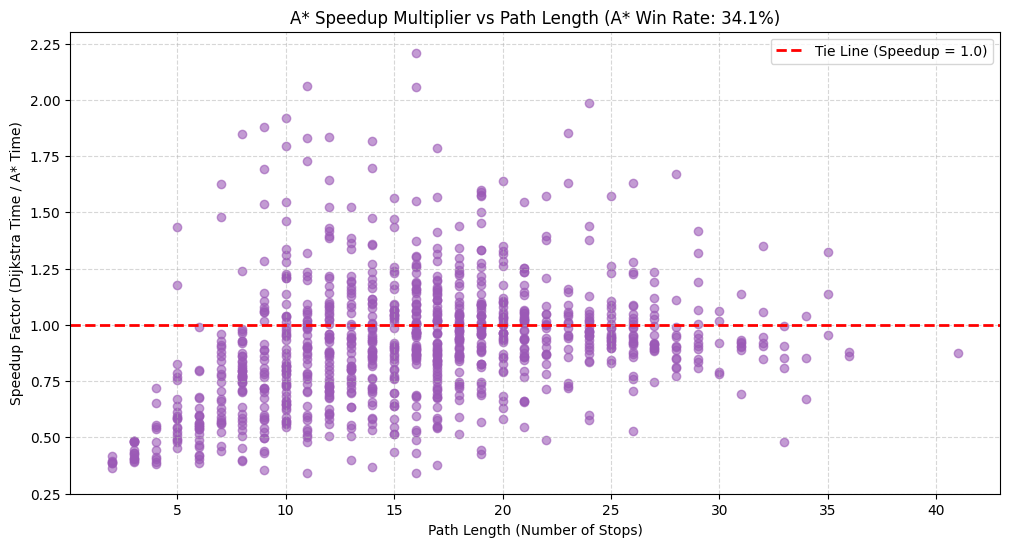

In [44]:
G = LondonTubeGraph()
G.load_stations("data/london_stations.csv")
G.load_connections("data/london_connections.csv")


test_suite_1_speedup(G, 1000)

Running Suite 2 (Goldilocks Transfers): 1000 routes...


C:\Users\heema\AppData\Local\Temp\ipykernel_116076\1294509944.py:151: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=valid_transfers, patch_artist=True,


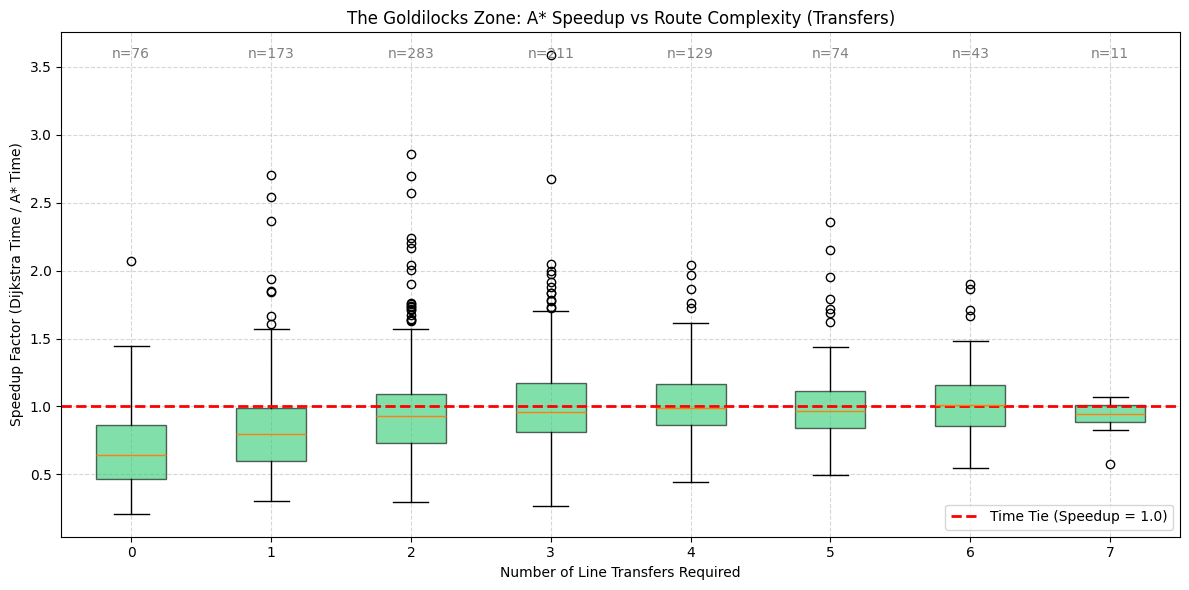

In [ ]:
test_suite_2_transfers(G, 1000)

Running Suite 3: 1000 routes...


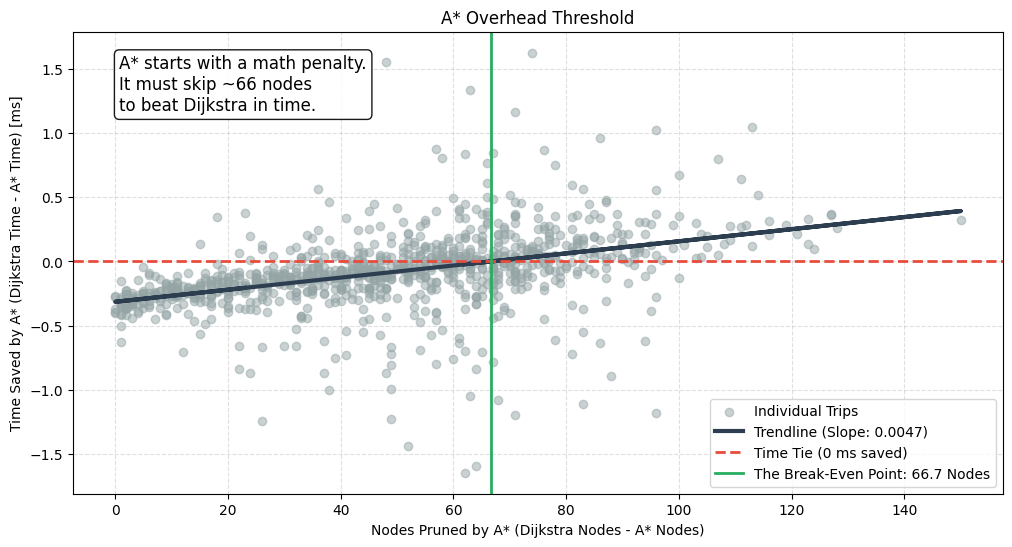

To overcome the computational overhead of the Haversine formula,
A* must prune exactly 66.69 nodes from the search space.
Or 22.08 percent of nodes


In [45]:
test_suite_3_break_even(G, 1000)